In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json


#📌 Extracción

In [3]:
datos = pd.read_json('/content/TelecomX_Data.json')
datos.head()

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


al cargar el json los diccionarios anidados no se aplanan, voy a abrir la base de datos de la otra manera para asegurar que todos los datos, aún los anidados queden en una sola tabla de datos.

In [4]:
with open('/content/TelecomX_Data.json', 'r', encoding='utf-8') as f:
    datos = json.load(f)


#🔧 Transformación

In [5]:
datos = pd.json_normalize(datos, sep='_')
display(datos.head())
print(datos.columns.tolist())

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


['customerID', 'Churn', 'customer_gender', 'customer_SeniorCitizen', 'customer_Partner', 'customer_Dependents', 'customer_tenure', 'phone_PhoneService', 'phone_MultipleLines', 'internet_InternetService', 'internet_OnlineSecurity', 'internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_Contract', 'account_PaperlessBilling', 'account_PaymentMethod', 'account_Charges_Monthly', 'account_Charges_Total']


In [6]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

Cambiare a numero la columna de total que al importarse quedó como objeto

In [7]:
datos['account_Charges_Total'] = pd.to_numeric(
    datos['account_Charges_Total'],
    errors='coerce'
)     #me tocó poner la linea de error porque cada que reconecto esta celda de codigo me marcaba error

In [8]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

Al hacer el cambio a número de la columna de account_changes_Total veo que ya no es la misma cantidad de datos que antes lo que me hace pensar que hay celdas vacias, lo voy a comprobar

In [9]:

datos[pd.to_numeric(datos['account_Charges_Total'], errors='coerce').isna()]

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,...,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total
975,1371-DWPAZ,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN
1775,2520-SGTTA,No,Female,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN
1955,2775-SEFEE,No,Male,0,No,Yes,0,Yes,Yes,DSL,...,Yes,No,Yes,No,No,Two year,Yes,Bank transfer (automatic),61.90,NaN
2075,2923-ARZLG,No,Male,0,Yes,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN
2232,3115-CZMZD,No,Male,0,No,Yes,0,Yes,No,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN
2308,3213-VVOLG,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN
2930,4075-WKNIU,No,Female,0,Yes,Yes,0,Yes,Yes,DSL,...,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN
3134,4367-NUYAO,No,Male,0,Yes,Yes,0,Yes,Yes,No,...,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN
3203,4472-LVYGI,No,Female,0,Yes,Yes,0,No,No phone service,DSL,...,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN
4169,5709-LVOEQ,No,Female,0,Yes,Yes,0,Yes,No,DSL,...,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN


In [10]:
datos.isna().sum()

,0
customerID,0
Churn,0
customer_gender,0
customer_SeniorCitizen,0
customer_Partner,0
customer_Dependents,0
customer_tenure,0
phone_PhoneService,0
phone_MultipleLines,0
internet_InternetService,0


Las celdas que estan sin datos las voy a llenar con cero para así no tener celdas vacias

In [11]:
datos['account_Charges_Total'].fillna(0, inplace=True)

/tmp/ipykernel_510/545611337.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  datos['account_Charges_Total'].fillna(0, inplace=True)


In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   customerID                 7267 non-null   object 
 1   Churn                      7267 non-null   object 
 2   customer_gender            7267 non-null   object 
 3   customer_SeniorCitizen     7267 non-null   int64  
 4   customer_Partner           7267 non-null   object 
 5   customer_Dependents        7267 non-null   object 
 6   customer_tenure            7267 non-null   int64  
 7   phone_PhoneService         7267 non-null   object 
 8   phone_MultipleLines        7267 non-null   object 
 9   internet_InternetService   7267 non-null   object 
 10  internet_OnlineSecurity    7267 non-null   object 
 11  internet_OnlineBackup      7267 non-null   object 
 12  internet_DeviceProtection  7267 non-null   object 
 13  internet_TechSupport       7267 non-null   objec

la otra inconsistencia que tal vez no sea tan reelevante pero la quiero manejar es la de la columna de senior, esta como numeríca pero para practicar la voy a poner como categorica

In [13]:
datos['customer_SeniorCitizen'] = datos['customer_SeniorCitizen'].astype('category')

In [14]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   customerID                 7267 non-null   object  
 1   Churn                      7267 non-null   object  
 2   customer_gender            7267 non-null   object  
 3   customer_SeniorCitizen     7267 non-null   category
 4   customer_Partner           7267 non-null   object  
 5   customer_Dependents        7267 non-null   object  
 6   customer_tenure            7267 non-null   int64   
 7   phone_PhoneService         7267 non-null   object  
 8   phone_MultipleLines        7267 non-null   object  
 9   internet_InternetService   7267 non-null   object  
 10  internet_OnlineSecurity    7267 non-null   object  
 11  internet_OnlineBackup      7267 non-null   object  
 12  internet_DeviceProtection  7267 non-null   object  
 13  internet_TechSupport       7267 n

In [15]:
# Se pide crear una columna de cuentas_diarias a partir de la facturación mensual obteniendo el promedio diario

datos['Cuentas_Diarias']=(datos['account_Charges_Monthly']/30).round(2)

In [16]:
pd.set_option('display.max_columns', None)
datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.40,2.80


Se pide camabiar las celdas que tienen valores textuales de Yes/No a 1/0, ademas de traducir los indices de las columnas


In [17]:
# datos['Churn'] = datos['Churn'].map({'Yes': 1, 'No': 0})    #Para una sola columna

# Para todas las columnas que tienen Yes / No

columnas = ['Churn', 'customer_Partner', 'customer_Dependents', 'phone_PhoneService', 'phone_MultipleLines','internet_OnlineSecurity','internet_OnlineBackup', 'internet_DeviceProtection', 'internet_TechSupport', 'internet_StreamingTV', 'internet_StreamingMovies', 'account_PaperlessBilling']

for col in columnas:
    datos[col] = datos[col].map({'Yes':1, 'No':0})

In [18]:
datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0.0,Female,0,1,1,9,1,0.0,DSL,0.0,1.0,0.0,1.0,1.0,0.0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0.0,Male,0,0,0,9,1,1.0,DSL,0.0,0.0,0.0,0.0,0.0,1.0,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1.0,Male,0,0,0,4,1,0.0,Fiber optic,0.0,0.0,1.0,0.0,0.0,0.0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1.0,Male,1,1,0,13,1,0.0,Fiber optic,0.0,1.0,1.0,0.0,1.0,1.0,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1.0,Female,1,1,0,3,1,0.0,Fiber optic,0.0,0.0,0.0,1.0,1.0,0.0,Month-to-month,1,Mailed check,83.9,267.40,2.80


In [19]:
#Me dejó en decimal, los voy aconvertir a entero

datos[columnas] = datos[columnas].fillna(0).astype(int)

In [20]:
datos.head()

,customerID,Churn,customer_gender,customer_SeniorCitizen,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_InternetService,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_Contract,account_PaperlessBilling,account_PaymentMethod,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
0,0002-ORFBO,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,65.6,593.30,2.19
1,0003-MKNFE,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,59.9,542.40,2.00
2,0004-TLHLJ,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,73.9,280.85,2.46
3,0011-IGKFF,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,98.0,1237.85,3.27
4,0013-EXCHZ,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,83.9,267.40,2.80


#📊 Carga y análisis

## Análisis Descriptivo

In [21]:
datos.describe()

,Churn,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
count,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000,7267.000000
mean,0.257190,0.484106,0.300124,32.346498,0.902711,0.421770,0.285950,0.344571,0.342782,0.289528,0.383927,0.387505,0.593230,64.720098,2277.182035,2.157292
std,0.437115,0.499782,0.458343,24.571773,0.296371,0.493876,0.451897,0.475261,0.474672,0.453575,0.486374,0.487214,0.491265,30.129572,2268.648587,1.004407
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.250000,0.000000,0.610000
25%,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,35.425000,396.200000,1.180000
50%,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,70.300000,1389.200000,2.340000
75%,1.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,89.875000,3778.525000,2.995000
max,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,118.750000,8684.800000,3.960000


##Distribución de evasión

me piden graficar el comportamiento de churn:
En este paso, el objetivo es comprender cómo está distribuida la variable "churn" (evasión) entre los clientes. Utiliza gráficos para visualizar la proporción de clientes que permanecieron y los que se dieron de baja.

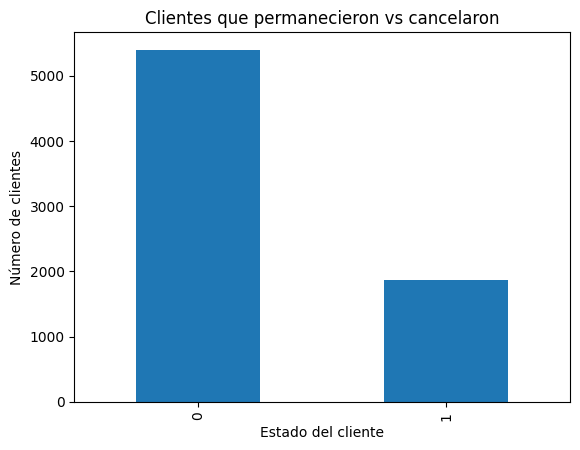

In [22]:
datos['Churn'].value_counts().plot(kind='bar')

plt.title('Clientes que permanecieron vs cancelaron')
plt.xlabel('Estado del cliente')
plt.ylabel('Número de clientes')
plt.show()

Con Seaborn para mejor vista

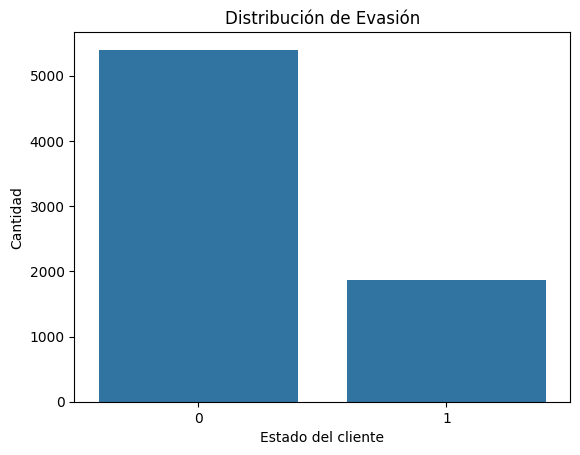

In [23]:
sns.countplot(x='Churn', data=datos)

plt.title('Distribución de Evasión')
plt.xlabel('Estado del cliente')
plt.ylabel('Cantidad')
plt.show()

##Recuento de evasión por variables categóricas

Ahora piden: explorar cómo se distribuye la evasión según variables categóricas, como género, tipo de contrato, método de pago, entre otras.

Este análisis puede revelar patrones interesantes, por ejemplo, si los clientes de ciertos perfiles tienen una mayor tendencia a cancelar el servicio, lo que ayudará a orientar acciones estratégicas.

In [24]:
#Analizaré primero por genero

(pd.crosstab(datos['customer_gender'], datos['Churn'], normalize='index') * 100).round(2)

Churn,0,1
customer_gender,,
Female,73.86,26.14
Male,74.69,25.31


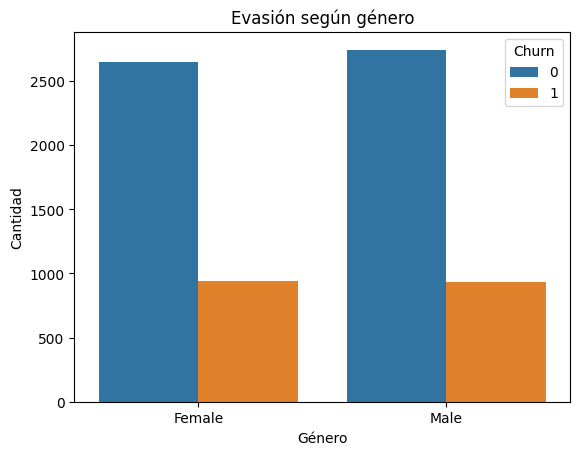

In [25]:
sns.countplot(x='customer_gender', hue='Churn', data=datos)

plt.title('Evasión según género')
plt.xlabel('Género')
plt.ylabel('Cantidad')
plt.show()

In [26]:
#Analizando por contrato

(pd.crosstab(datos['account_Contract'], datos['Churn'], normalize='index') * 100).round(2)

Churn,0,1
account_Contract,,
Month-to-month,58.68,41.32
One year,89.07,10.93
Two year,97.25,2.75


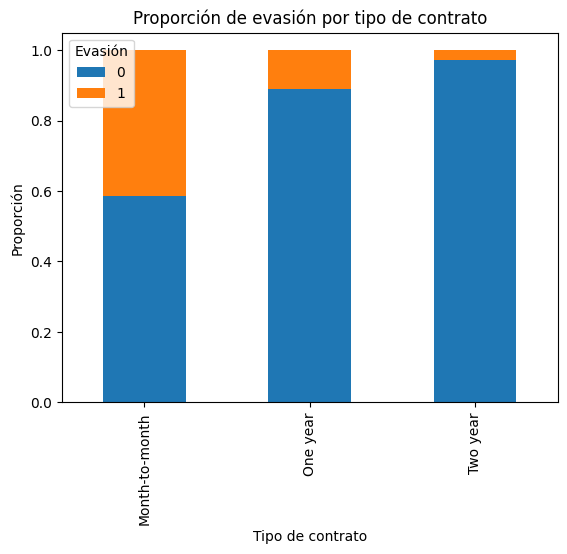

In [27]:
contrato_churn = pd.crosstab(
    datos['account_Contract'],
    datos['Churn'],
    normalize='index'
)

contrato_churn.plot(kind='bar', stacked=True)

plt.title('Proporción de evasión por tipo de contrato')
plt.ylabel('Proporción')
plt.xlabel('Tipo de contrato')
plt.legend(title='Evasión')
plt.show()

Mejor voy a tratar de analizar mas variables a la vez

In [28]:
columnas_analisis = [
'customer_gender',
'customer_SeniorCitizen',
'customer_Partner',
'customer_Dependents',
'phone_PhoneService',
'internet_InternetService',
'account_Contract',
'account_PaymentMethod'
]

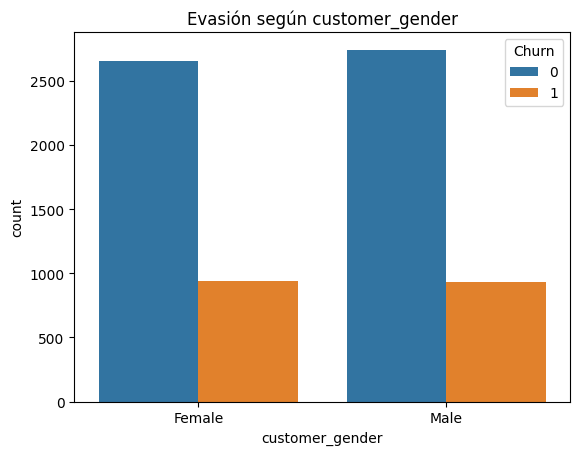

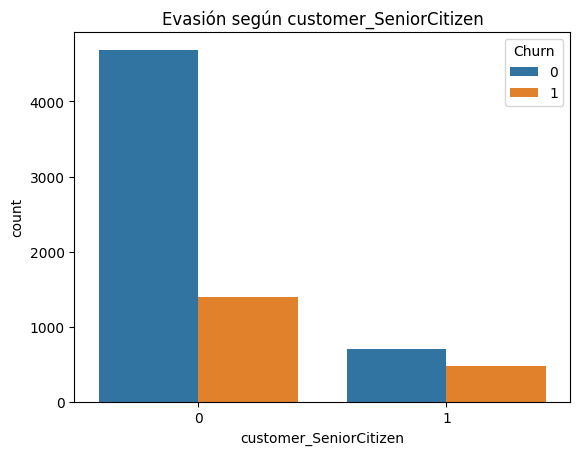

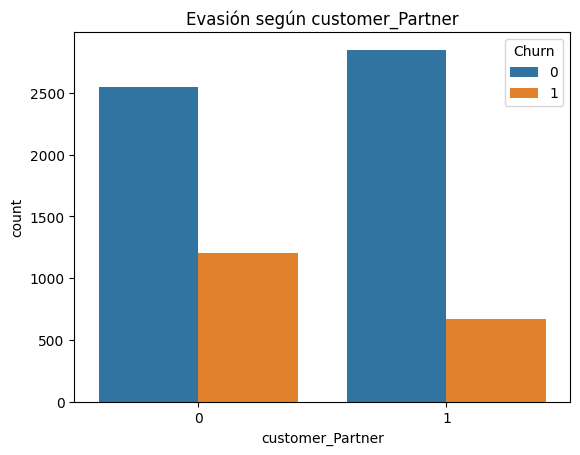

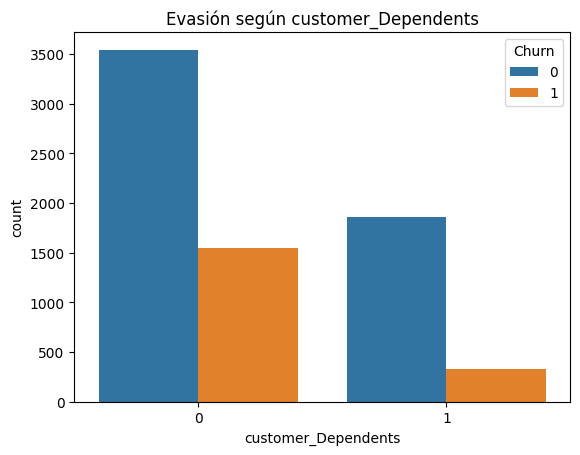

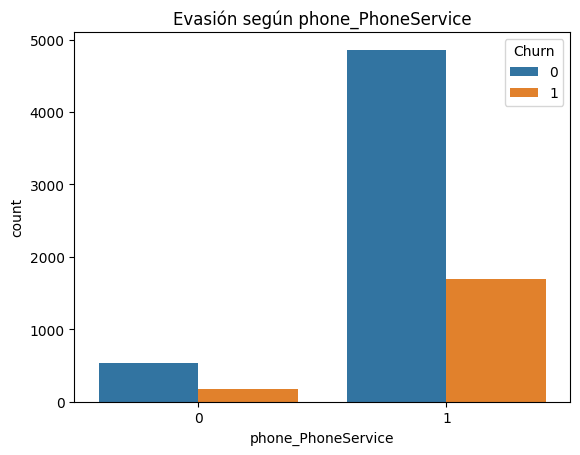

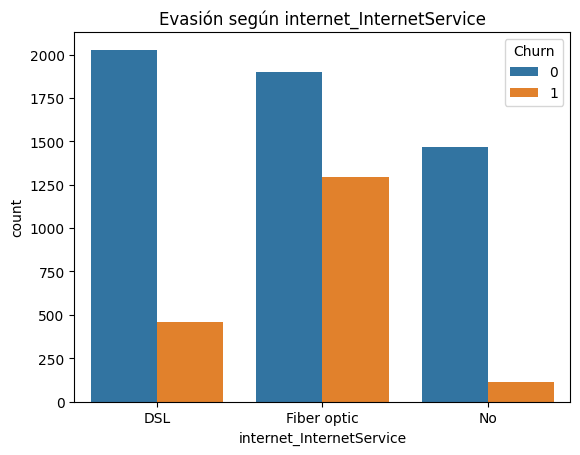

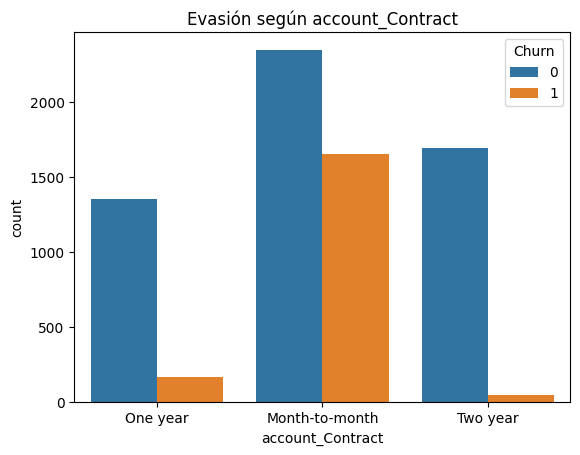

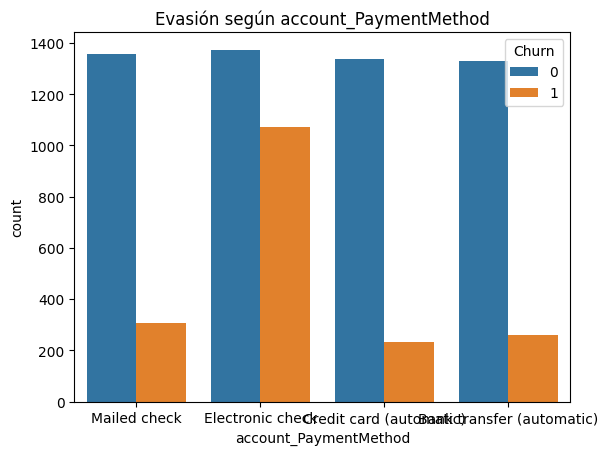

In [29]:
for col in columnas_analisis:
    sns.countplot(x=col, hue='Churn', data=datos)
    plt.title(f'Evasión según {col}')
    plt.show()

##Conteo de evasión por variables numéricas

Tambien se pide conteo por evasión por variables numéricas

En este paso, explora cómo las variables numéricas, como "total gastado" o "tiempo de contrato", se distribuyen entre los clientes que cancelaron (evasión) y los que no cancelaron.

Este análisis ayuda a entender si ciertos valores numéricos están más asociados con la evasión, proporcionando insights sobre los factores que influyen en el comportamiento de los clientes.

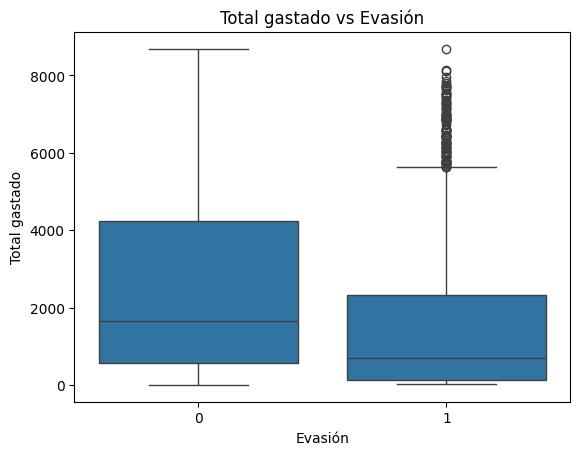

In [30]:
#voy a comenzar poneindo en práctica el boxplot

sns.boxplot(x='Churn', y='account_Charges_Total', data=datos)

plt.title('Total gastado vs Evasión')
plt.xlabel('Evasión')
plt.ylabel('Total gastado')
plt.show()

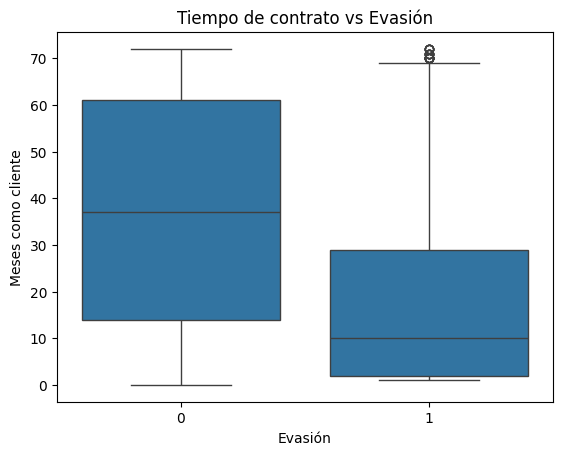

In [31]:
sns.boxplot(x='Churn', y='customer_tenure', data=datos)

plt.title('Tiempo de contrato vs Evasión')
plt.xlabel('Evasión')
plt.ylabel('Meses como cliente')
plt.show()

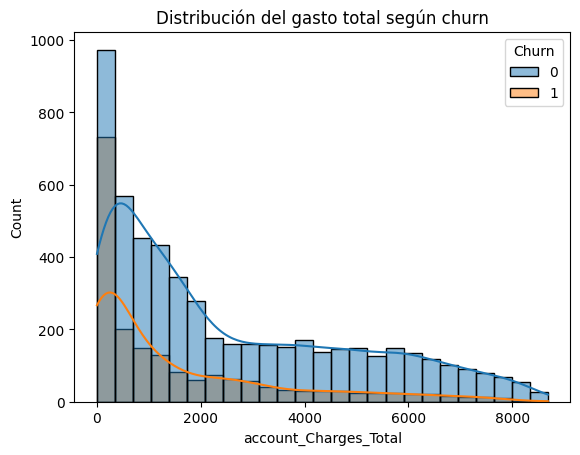

In [32]:
sns.histplot(data=datos, x='account_Charges_Total', hue='Churn', kde=True)

plt.title('Distribución del gasto total según Evasión')
plt.show()

#📄Informe final

Finaliza el desafío elaborando un informe dentro del mismo notebook que resuma todo el trabajo realizado. El informe debe incluir:

🔹 Introducción: Explica el objetivo del análisis y el problema de evasión de clientes (Churn).

🔹 Limpieza y Tratamiento de Datos: Describe los pasos realizados para importar, limpiar y procesar los datos.

🔹 Análisis Exploratorio de Datos: Presenta los análisis realizados, incluyendo gráficos y visualizaciones para identificar patrones.

🔹 Conclusiones e Insights: Resume los principales hallazgos y cómo estos datos pueden ayudar a reducir la evasión.

🔹 Recomendaciones: Ofrece sugerencias estratégicas basadas en tu análisis.

Asegúrate de que el informe esté bien estructurado, claro y respaldado por visualizaciones que refuercen tus conclusiones. 🚀



## Informe



Se tiene una compañia telefonica que quiere analizar el comportameitno de la evasión del pago de os clientes, para ello se proporciona una tabla con formato JSON con datos agrupados en diccionarios internos, para poder tabajar con los datos primero se requirió de coloarlos todos sn una tabla, esto se hizo con la lectura, nirmalización y agrupamiento de los datos.

Una vez que se tuvo la tabla "aplanada" con todos los datos proporcionados, se nalizaron los tipos de variable y como los acomodo la biblioteca JSON y pandas, se noto que algunas de las columas se clasificaron como objeto pero en relaida se podian tratar como núimero, así que se cambio el tipo de dato, se notó que en la columna de totales habian 11 celadas vacias, se visualizaron y se rellenaron con datos de "cero" para tratar de afectar lo maneo sposible el analisis de los mismos.
Una vez que se tiene la tabla arregada de inconsistencias, se proceió a cmabiar tambein el tipo de varibales booleanas a ceros y unos, para así ya poser hacer una visualización de los datos y realizar su analisis corespondinte.
PAra visualizar y analizar el comprtamiento de los datos, primero se analizaron las varibales categoricas y se correlacionaron con le evasión para ello se utilzairon diferetnes tipos de gráficos, y de igual manera al final se analizó el comportamiento de las variables numericas de gasto y tiempo de contrato haciendo uso de graficos de caja.

Con todo lo anterior se puede deducir lo siguiente:

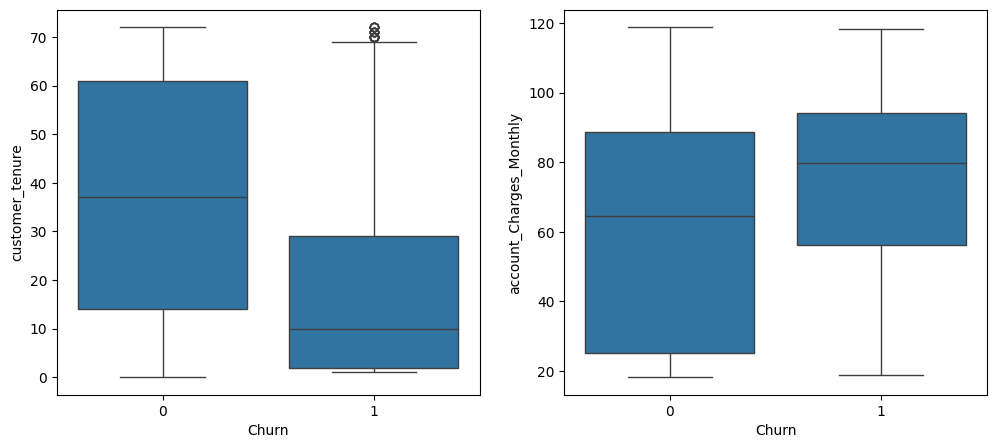

In [39]:
fig, ax = plt.subplots(1,2, figsize=(12,5))

sns.boxplot(x='Churn', y='customer_tenure', data=datos, ax=ax[0])
sns.boxplot(x='Churn', y='account_Charges_Monthly', data=datos, ax=ax[1])

plt.show()

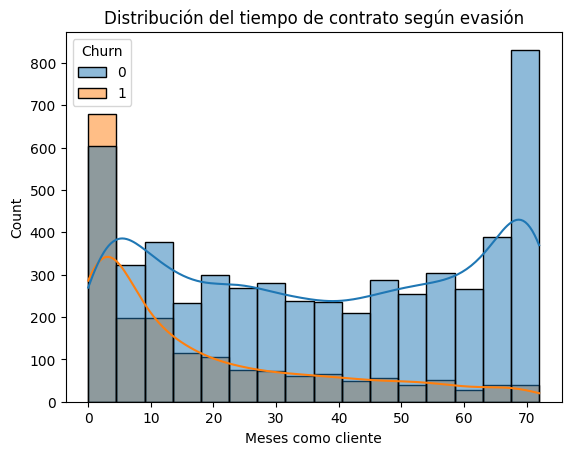

In [40]:
sns.histplot(data=datos, x='customer_tenure', hue='Churn', kde=True)

plt.title('Distribución del tiempo de contrato según evasión')
plt.xlabel('Meses como cliente')
plt.show()

Se tiene una mayor evasión en clientes que tienen poco tiempo de contrato comparados con aquellos que ya tienen más periodo con el servicio. También es notorio que los clientes que eligen un plazo de contrato mas corto son los que evanden más.

En el caso del genero no se presta evidencia que alguno de ellos sea mas evasor que otro, el comportameitno es el mismo.

También es de destacar que los senir aunque son menos clientes respecto a los que no son senior estos presentan una tasa de evasión mas alta.

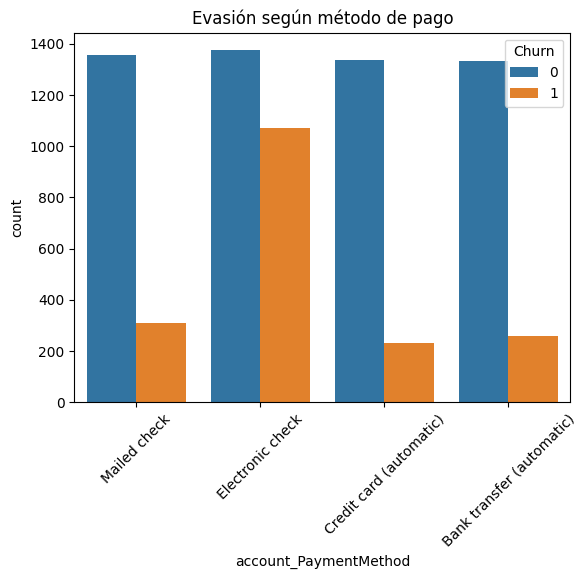

In [36]:
sns.countplot(x='account_PaymentMethod', hue='Churn', data=datos)

plt.title('Evasión según método de pago')
plt.xticks(rotation=45)  # opcional para que se lean mejor
plt.show()

### Recomendación para reducir la evasión

De acuerdo a lo observado, se recomienda ampliamente promover los contratos a mayor plazo, tal vez ofreceindo algunos incentivos como descuentos, megas, redes sociales, etc.

Lo que noté también es que los que pagan con cheque electrónico (ver gráfica compartiva de pagos) son los que mas evaden, así que promover el pago con  pago automatico puede ser una buena alternativa para disminiur la evasión.


# Correlación

Se pide hacer la correlación, está la hare (por ahora) solo con las variables numéricas

In [41]:
datos_numericos = datos.select_dtypes(include=['int64','float64'])

In [43]:
correlacion = datos_numericos.corr()
correlacion

,Churn,customer_Partner,customer_Dependents,customer_tenure,phone_PhoneService,phone_MultipleLines,internet_OnlineSecurity,internet_OnlineBackup,internet_DeviceProtection,internet_TechSupport,internet_StreamingTV,internet_StreamingMovies,account_PaperlessBilling,account_Charges_Monthly,account_Charges_Total,Cuentas_Diarias
Churn,1.000000,-0.148546,-0.161384,-0.344079,0.012571,0.039343,-0.166828,-0.080163,-0.063452,-0.160440,0.062430,0.060586,0.186666,0.189866,-0.193345,0.189918
customer_Partner,-0.148546,1.000000,0.448900,0.377551,0.018828,0.141187,0.141392,0.139523,0.153209,0.116228,0.124754,0.115729,-0.011201,0.097122,0.315409,0.097180
customer_Dependents,-0.161384,0.448900,1.000000,0.159892,-0.003863,-0.027894,0.083951,0.023686,0.014797,0.062586,-0.015030,-0.040151,-0.111752,-0.115832,0.061474,-0.115879
customer_tenure,-0.344079,0.377551,0.159892,1.000000,0.010205,0.331678,0.327252,0.361291,0.361792,0.322139,0.280738,0.286841,0.007949,0.247982,0.825407,0.247992
phone_PhoneService,0.012571,0.018828,-0.003863,0.010205,1.000000,0.280379,-0.093341,-0.052165,-0.073033,-0.097573,-0.025362,-0.034345,0.013624,0.246709,0.113985,0.246668
phone_MultipleLines,0.039343,0.141187,-0.027894,0.331678,0.280379,1.000000,0.098396,0.205156,0.202172,0.098053,0.257405,0.259268,0.163225,0.490699,0.468405,0.490712
internet_OnlineSecurity,-0.166828,0.141392,0.083951,0.327252,-0.093341,0.098396,1.000000,0.286432,0.275699,0.356113,0.177332,0.189881,-0.001693,0.298307,0.412764,0.298303
internet_OnlineBackup,-0.080163,0.139523,0.023686,0.361291,-0.052165,0.205156,0.286432,1.000000,0.306665,0.292422,0.283195,0.276788,0.131187,0.442974,0.512027,0.442954
internet_DeviceProtection,-0.063452,0.153209,0.014797,0.361792,-0.073033,0.202172,0.275699,0.306665,1.000000,0.332267,0.394421,0.402720,0.105211,0.483590,0.523836,0.483549
internet_TechSupport,-0.160440,0.116228,0.062586,0.322139,-0.097573,0.098053,0.356113,0.292422,0.332267,1.000000,0.278376,0.280058,0.037581,0.338429,0.431032,0.338436


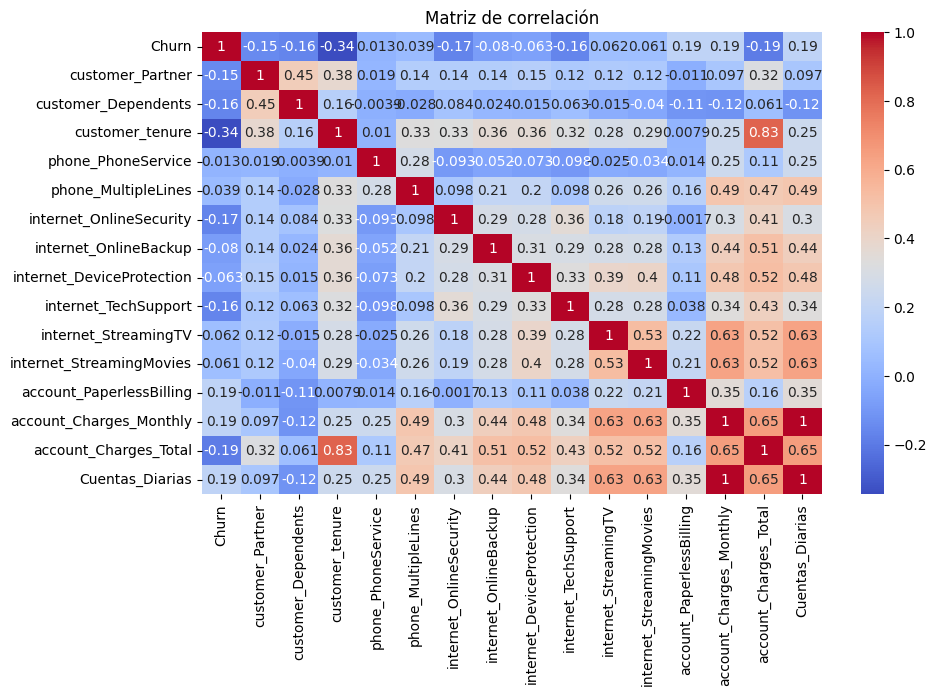

In [44]:
plt.figure(figsize=(10,6))
sns.heatmap(correlacion, annot=True, cmap='coolwarm')

plt.title('Matriz de correlación')
plt.show()

In [45]:
correlacion_churn = datos_numericos.corr()['Churn'].sort_values(ascending=False)
print(correlacion_churn)

Churn                        1.000000
Cuentas_Diarias              0.189918
account_Charges_Monthly      0.189866
account_PaperlessBilling     0.186666
internet_StreamingTV         0.062430
internet_StreamingMovies     0.060586
phone_MultipleLines          0.039343
phone_PhoneService           0.012571
internet_DeviceProtection   -0.063452
internet_OnlineBackup       -0.080163
customer_Partner            -0.148546
internet_TechSupport        -0.160440
customer_Dependents         -0.161384
internet_OnlineSecurity     -0.166828
account_Charges_Total       -0.193345
customer_tenure             -0.344079
Name: Churn, dtype: float64
